# Dataset analysis

Hero pick counts and win rates across complete parsed matches.

In [52]:
import importlib
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "scripts").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

import scripts.ml.dataset as dataset_module

importlib.reload(dataset_module)

DatasetMaker = dataset_module.DatasetMaker
HERO_ALIASES = dataset_module.HERO_ALIASES
HEROES_PATH = dataset_module.HEROES_PATH
normalize_hero_name = dataset_module.normalize_hero_name

In [53]:
HERO_PICK_STATS_QUERY = """
    WITH complete_matches AS (
        SELECT
            m.match_id
        FROM dotabuff_matches m
        JOIN dotabuff_match_players p ON p.match_id = m.match_id
        WHERE
            m.winner_side IN ('radiant', 'dire')
            AND p.side IN ('radiant', 'dire')
            AND p.hero_slug IS NOT NULL
        GROUP BY m.match_id
        HAVING
            COUNT(*) = 10
            AND COUNT(*) FILTER (WHERE p.side = 'radiant') = 5
            AND COUNT(*) FILTER (WHERE p.side = 'dire') = 5
    )
    SELECT
        p.hero_slug,
        COUNT(*)::int AS appearances,
        COUNT(*) FILTER (WHERE p.side = m.winner_side)::int AS wins,
        COUNT(*) FILTER (WHERE p.side = 'radiant')::int AS radiant_picks,
        COUNT(*) FILTER (WHERE p.side = 'dire')::int AS dire_picks,
        COUNT(*) FILTER (WHERE p.side = 'radiant' AND m.winner_side = 'radiant')::int AS radiant_wins,
        COUNT(*) FILTER (WHERE p.side = 'dire' AND m.winner_side = 'dire')::int AS dire_wins
    FROM complete_matches cm
    JOIN dotabuff_matches m ON m.match_id = cm.match_id
    JOIN dotabuff_match_players p ON p.match_id = cm.match_id
    WHERE
        p.side IN ('radiant', 'dire')
        AND p.hero_slug IS NOT NULL
    GROUP BY p.hero_slug
    ORDER BY appearances DESC
"""

In [54]:
def load_hero_name_by_key(path=HEROES_PATH):
    heroes = json.loads(Path(path).read_text(encoding="utf-8"))
    names = {}

    for hero in heroes.values():
        localized_name = hero.get("localized_name")
        internal_name = hero.get("name")
        if not localized_name:
            continue

        names[normalize_hero_name(localized_name)] = localized_name
        if internal_name:
            short_name = internal_name.removeprefix("npc_dota_hero_")
            names[normalize_hero_name(short_name)] = localized_name

    return names


hero_name_by_key = load_hero_name_by_key()


def canonical_hero_key(value):
    key = normalize_hero_name(value)
    return HERO_ALIASES.get(key, key)


def hero_display_name(canonical_key):
    return hero_name_by_key.get(canonical_key, canonical_key)

In [55]:
with DatasetMaker(env_file=str(PROJECT_ROOT / ".env")) as dataset:
    with dataset._conn.cursor() as cur:
        cur.execute(HERO_PICK_STATS_QUERY)
        rows = cur.fetchall()

raw_stats = pd.DataFrame(rows)
raw_stats.head(), raw_stats.shape

(  hero_slug  appearances  wins  radiant_picks  dire_picks  radiant_wins  \
 0    jakiro          861   417            406         455           203   
 1      tusk          747   348            395         352           188   
 2  hoodwink          693   362            334         359           173   
 3      tiny          601   293            282         319           144   
 4      puck          594   280            286         308           130   
 
    dire_wins  
 0        214  
 1        160  
 2        189  
 3        149  
 4        150  ,
 (127, 7))

In [56]:
stats = raw_stats.copy()
stats["hero_key"] = stats["hero_slug"].map(canonical_hero_key)

hero_stats = (
    stats.groupby("hero_key", as_index=False)[
        ["appearances", "wins", "radiant_picks", "dire_picks", "radiant_wins", "dire_wins"]
    ]
    .sum()
    .assign(
        hero=lambda df: df["hero_key"].map(hero_display_name),
        win_rate=lambda df: df["wins"] / df["appearances"],
        radiant_win_rate=lambda df: df["radiant_wins"] / df["radiant_picks"].where(df["radiant_picks"] > 0),
        dire_win_rate=lambda df: df["dire_wins"] / df["dire_picks"].where(df["dire_picks"] > 0),
    )
    .sort_values(["appearances", "win_rate"], ascending=[False, False])
)

hero_stats = hero_stats[
    [
        "hero",
        "hero_key",
        "appearances",
        "wins",
        "win_rate",
        "radiant_picks",
        "radiant_wins",
        "radiant_win_rate",
        "dire_picks",
        "dire_wins",
        "dire_win_rate",
    ]
]

hero_stats.head(20)

,hero,hero_key,appearances,wins,win_rate,radiant_picks,radiant_wins,radiant_win_rate,dire_picks,dire_wins,dire_win_rate
42,Jakiro,jakiro,861,417,0.484321,406,203,0.500000,455,214,0.470330
111,Tusk,tusk,747,348,0.465863,395,188,0.475949,352,160,0.454545
38,Hoodwink,hoodwink,693,362,0.522367,334,173,0.517964,359,189,0.526462
108,Tiny,tiny,601,293,0.487521,282,144,0.510638,319,149,0.467085
80,Puck,puck,594,280,0.471380,286,130,0.454545,308,150,0.487013
59,Mars,mars,593,267,0.450253,303,137,0.452145,290,130,0.448276
120,Warlock,warlock,565,265,0.469027,270,122,0.451852,295,143,0.484746
89,Shadow Demon,shadowdemon,551,297,0.539020,278,158,0.568345,273,139,0.509158
32,Ember Spirit,emberspirit,547,288,0.526508,279,142,0.508961,268,146,0.544776
100,Storm Spirit,stormspirit,527,245,0.464896,266,130,0.488722,261,115,0.440613


In [57]:
hero_stats.tail(20)

,hero,hero_key,appearances,wins,win_rate,radiant_picks,radiant_wins,radiant_win_rate,dire_picks,dire_wins,dire_win_rate
72,Omniknight,omniknight,45,22,0.488889,21,12,0.571429,24,10,0.416667
61,Meepo,meepo,41,24,0.585366,22,13,0.590909,19,11,0.578947
3,Anti-Mage,antimage,41,20,0.487805,17,7,0.411765,24,13,0.541667
28,Drow Ranger,drowranger,35,14,0.400000,17,5,0.294118,18,9,0.500000
68,Necrophos,necrophos,35,13,0.371429,16,6,0.375000,19,7,0.368421
50,Lich,lich,35,11,0.314286,17,6,0.352941,18,5,0.277778
52,Lina,lina,33,15,0.454545,17,8,0.470588,16,7,0.437500
126,Zeus,zeus,29,17,0.586207,17,11,0.647059,12,6,0.500000
124,Witch Doctor,witchdoctor,23,12,0.521739,13,8,0.615385,10,4,0.400000
77,Phantom Lancer,phantomlancer,23,6,0.260870,13,5,0.384615,10,1,0.100000


In [58]:
summary = {
    "unique_raw_hero_slugs": raw_stats["hero_slug"].nunique(),
    "unique_canonical_heroes": hero_stats["hero_key"].nunique(),
    "total_hero_appearances": int(hero_stats["appearances"].sum()),
    "complete_matches": int(hero_stats["appearances"].sum() / 10),
}

summary

{'unique_raw_hero_slugs': 127,
 'unique_canonical_heroes': 127,
 'total_hero_appearances': 28110,
 'complete_matches': 2811}

In [60]:
MIN_APPEARANCES = 0

popular_heroes = hero_stats[hero_stats["appearances"] >= MIN_APPEARANCES]
popular_heroes.sort_values("win_rate", ascending=False).head(20)

,hero,hero_key,appearances,wins,win_rate,radiant_picks,radiant_wins,radiant_win_rate,dire_picks,dire_wins,dire_win_rate
4,Arc Warden,arcwarden,3,2,0.666667,2,1,0.500000,1,1,1.000000
54,Lone Druid,lonedruid,60,40,0.666667,21,14,0.666667,39,26,0.666667
48,Legion Commander,legioncommander,16,10,0.625000,9,6,0.666667,7,4,0.571429
39,Huskar,huskar,150,93,0.620000,75,45,0.600000,75,48,0.640000
13,Broodmother,broodmother,60,37,0.616667,30,18,0.600000,30,19,0.633333
109,Treant Protector,treantprotector,222,135,0.608108,98,64,0.653061,124,71,0.572581
47,Largo,largo,254,149,0.586614,106,60,0.566038,148,89,0.601351
126,Zeus,zeus,29,17,0.586207,17,11,0.647059,12,6,0.500000
61,Meepo,meepo,41,24,0.585366,22,13,0.590909,19,11,0.578947
9,Bloodseeker,bloodseeker,12,7,0.583333,4,4,1.000000,8,3,0.375000


In [ ]:
popular_heroes.sort_values("win_rate", ascending=True).head(20)

,hero,hero_key,appearances,wins,win_rate,radiant_picks,radiant_wins,radiant_win_rate,dire_picks,dire_wins,dire_win_rate
74,Outworld Devourer,outworlddevourer,8,2,0.250000,5,1,0.200000,3,1,0.333333
77,Phantom Lancer,phantomlancer,23,6,0.260870,13,5,0.384615,10,1,0.100000
50,Lich,lich,35,11,0.314286,17,6,0.352941,18,5,0.277778
22,Dawnbreaker,dawnbreaker,136,48,0.352941,82,29,0.353659,54,19,0.351852
55,Luna,luna,145,52,0.358621,71,28,0.394366,74,24,0.324324
68,Necrophos,necrophos,35,13,0.371429,16,6,0.375000,19,7,0.368421
28,Drow Ranger,drowranger,35,14,0.400000,17,5,0.294118,18,9,0.500000
101,Sven,sven,144,60,0.416667,66,22,0.333333,78,38,0.487179
110,Troll Warlord,trollwarlord,143,60,0.419580,74,33,0.445946,69,27,0.391304
93,Skywrath Mage,skywrathmage,172,74,0.430233,88,37,0.420455,84,37,0.440476


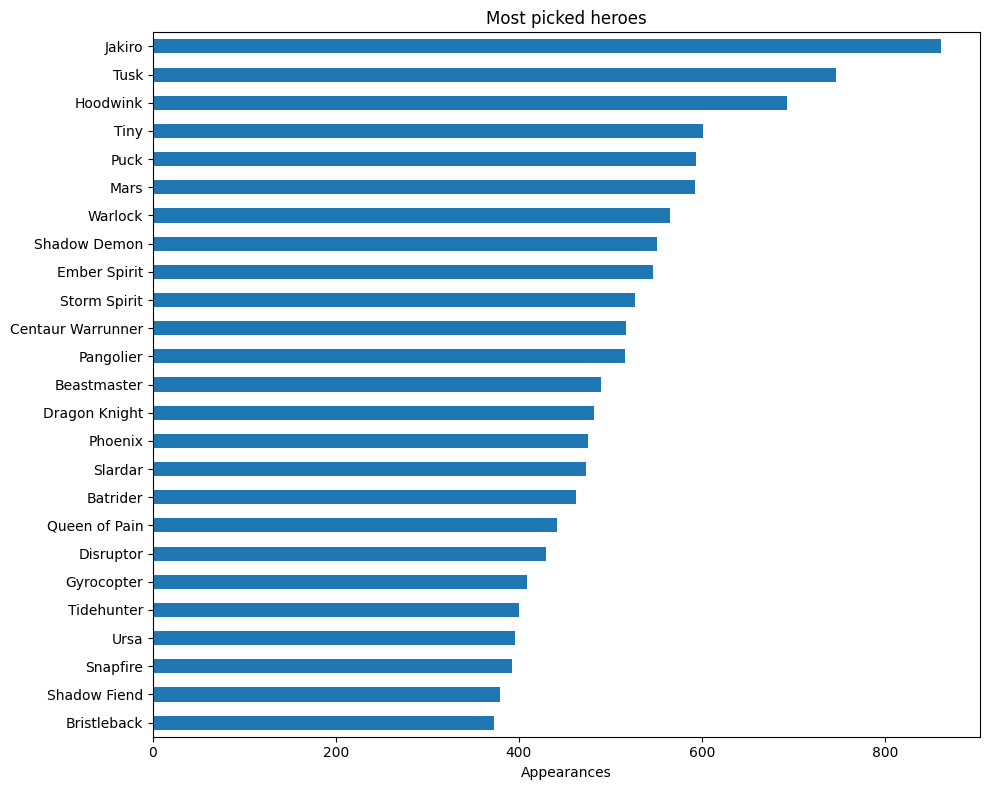

In [64]:
top_picked = hero_stats.sort_values("appearances", ascending=False).head(25).sort_values("appearances")

ax = top_picked.plot.barh(x="hero", y="appearances", figsize=(10, 8), legend=False)
ax.set_title("Most picked heroes")
ax.set_xlabel("Appearances")
ax.set_ylabel("")
plt.tight_layout()

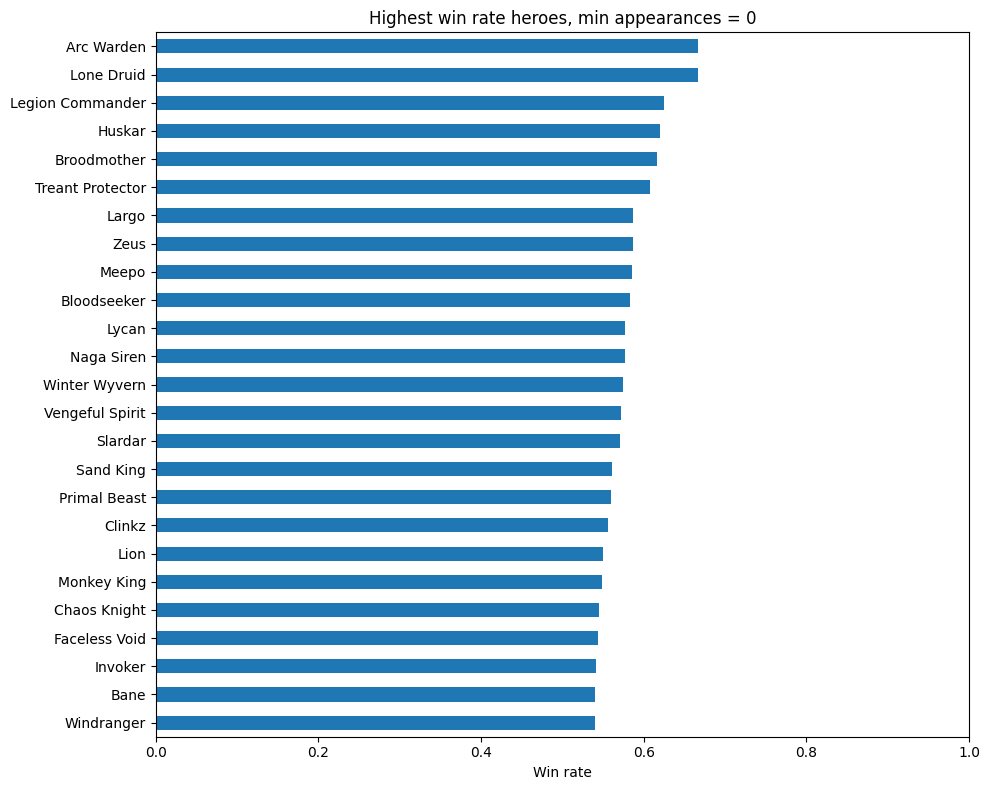

In [65]:
top_win_rate = popular_heroes.sort_values("win_rate", ascending=False).head(25).sort_values("win_rate")

ax = top_win_rate.plot.barh(x="hero", y="win_rate", figsize=(10, 8), legend=False)
ax.set_title(f"Highest win rate heroes, min appearances = {MIN_APPEARANCES}")
ax.set_xlabel("Win rate")
ax.set_ylabel("")
ax.set_xlim(0, 1)
plt.tight_layout()

## Histograms

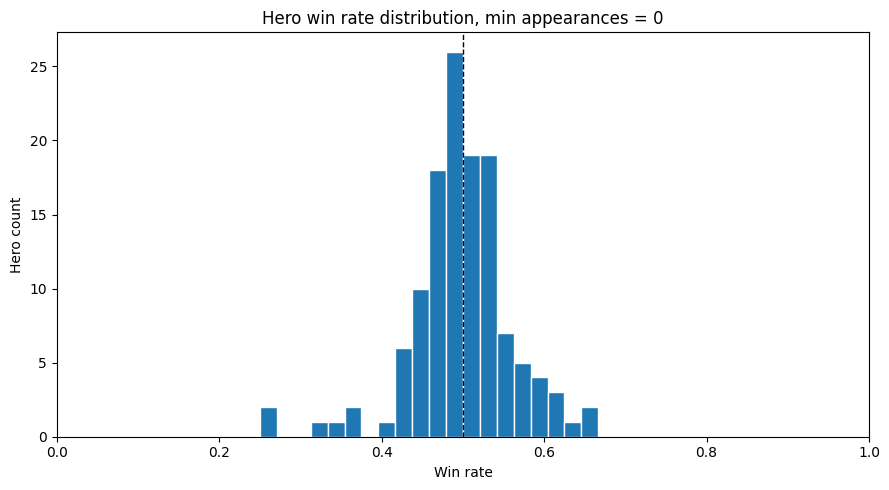

In [66]:
ax = popular_heroes["win_rate"].plot.hist(bins=20, figsize=(9, 5), edgecolor="white")
ax.axvline(0.5, color="black", linestyle="--", linewidth=1)
ax.set_title(f"Hero win rate distribution, min appearances = {MIN_APPEARANCES}")
ax.set_xlabel("Win rate")
ax.set_ylabel("Hero count")
ax.set_xlim(0, 1)
plt.tight_layout()

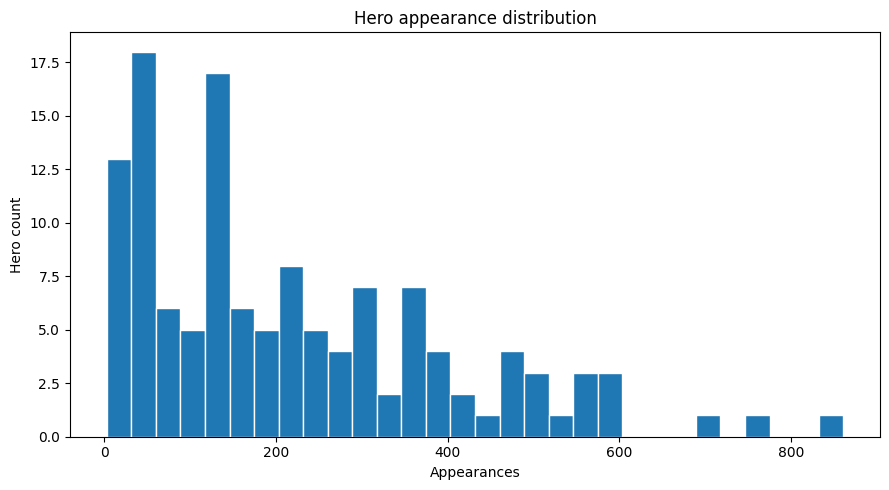

In [67]:
ax = hero_stats["appearances"].plot.hist(bins=30, figsize=(9, 5), edgecolor="white")
ax.set_title("Hero appearance distribution")
ax.set_xlabel("Appearances")
ax.set_ylabel("Hero count")
plt.tight_layout()